In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\sanan\OneDrive\Documents\Predictive_analysis\Project 03\water_potability.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [2]:
print('ph median:', df['ph'].median())

ph median: 7.036752103833548


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [4]:
#Handle Missing Values

df = df.fillna(df.median(numeric_only=True))

In [5]:
#Separate Features & Target

X = df.drop('Potability', axis=1)
y = df['Potability']

In [6]:
#Feature Scaling
#!pip install scikit-learn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [8]:
print('Before fillna:', df.isnull().sum())

Before fillna: ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [9]:
#Check Missing Values

df['ph'].fillna(df['ph'].median(), inplace=True)
df['Sulfate'].fillna(df['Sulfate'].median(), inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].median(), inplace=True)



C:\Users\sanan\AppData\Local\Temp\ipykernel_23040\3190039856.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['ph'].fillna(df['ph'].median(), inplace=True)
C:\Users\sanan\AppData\Local\Temp\ipykernel_23040\3190039856.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

0        86.990970
1        56.329076
2        66.420093
3       100.341674
4        31.997993
           ...    
3271     66.687695
3272     66.622485
3273     69.845400
3274     77.488213
3275     78.698446
Name: Trihalomethanes, Length: 3276, dtype: float64

In [10]:
print(df.isnull().sum())

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


In [11]:
#Separate Features & Target

X = df.drop('Potability', axis=1)
y = df['Potability']

In [12]:
#Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
import numpy as np
print('Std of X_train:', np.std(X_train, axis=0))

Std of X_train: ph                    1.462505
Hardness             32.572857
Solids             8833.392696
Chloramines           1.587732
Sulfate              36.194707
Conductivity         81.174047
Organic_carbon        3.284415
Trihalomethanes      15.844278
Turbidity             0.779013
dtype: float64


In [14]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_std=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
import numpy as np
print('NaN in X_train:', np.isnan(X_train).sum())
print('Shape X_train:', X_train.shape)

NaN in X_train: 0
Shape X_train: (2620, 9)


In [16]:
#Handle Imbalance

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

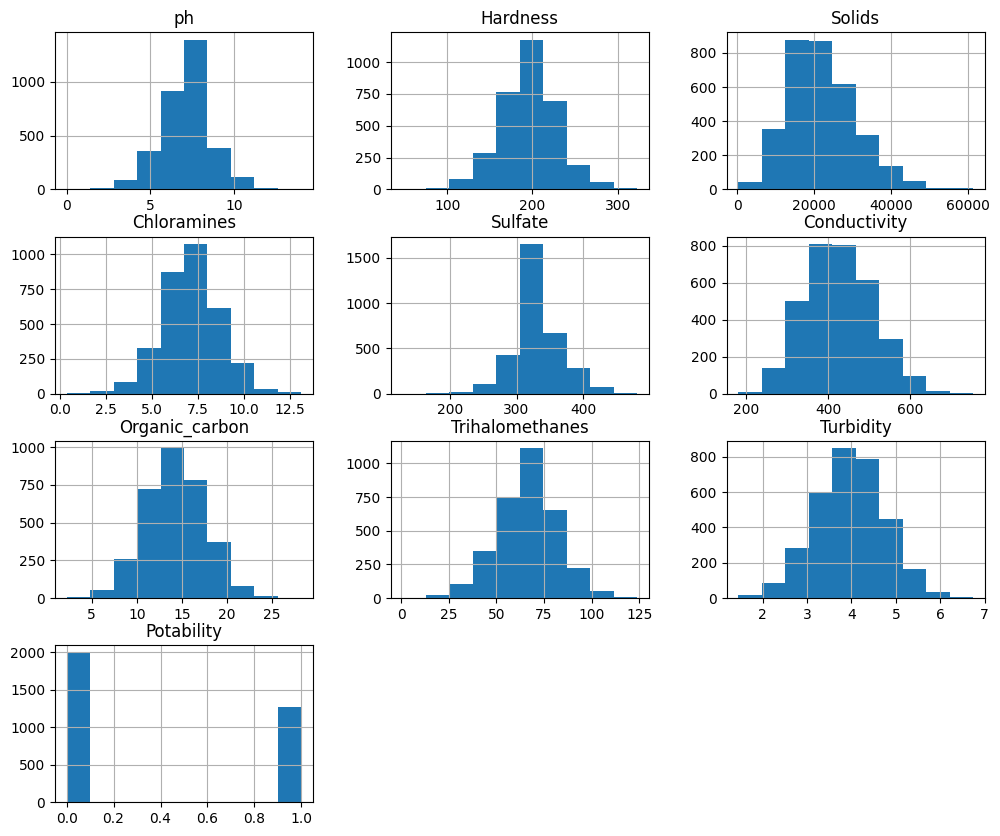

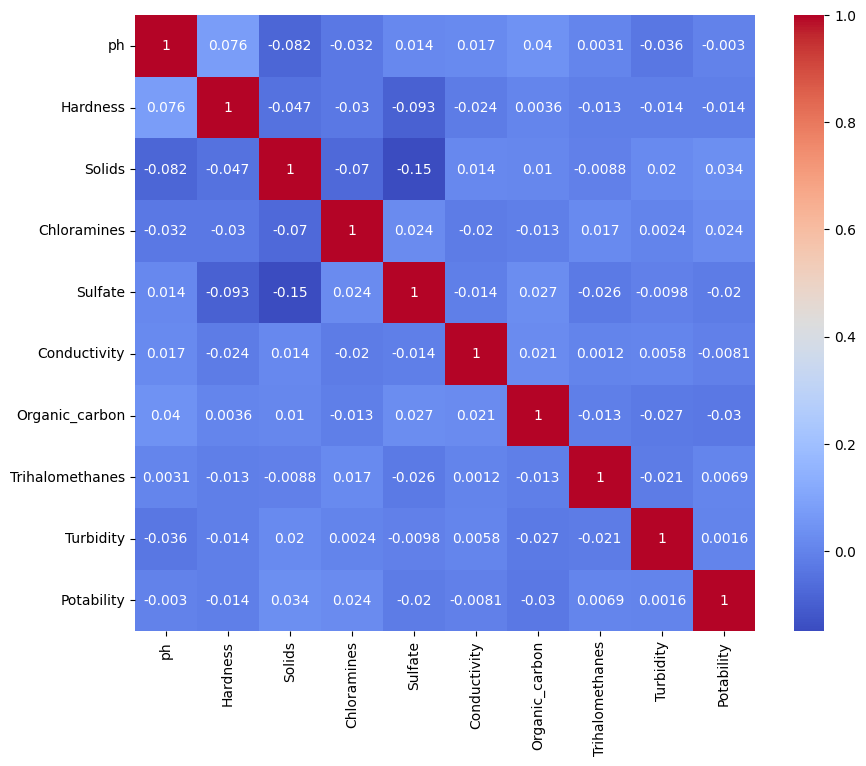

In [17]:
#EDA

import seaborn as sns
import matplotlib.pyplot as plt

# Distribution
df.hist(figsize=(12,10))
plt.show()

# Correlation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [18]:
#Model Training

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression()
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

c:\Users\sanan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
#Predictions

lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [20]:
#Accuracy

from sklearn.metrics import accuracy_score

print("LR:", accuracy_score(y_test, lr_pred))
print("DT:", accuracy_score(y_test, dt_pred))
print("RF:", accuracy_score(y_test, rf_pred))

LR: 0.5121951219512195
DT: 0.5655487804878049
RF: 0.6310975609756098


In [21]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, lr_pred))
print(confusion_matrix(y_test, dt_pred))
print(confusion_matrix(y_test, rf_pred))

[[214 198]
 [122 122]]
[[247 165]
 [120 124]]
[[290 122]
 [120 124]]


In [22]:
#Precision, Recall, F1-score

from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))
print(classification_report(y_test, dt_pred))
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.64      0.52      0.57       412
           1       0.38      0.50      0.43       244

    accuracy                           0.51       656
   macro avg       0.51      0.51      0.50       656
weighted avg       0.54      0.51      0.52       656

              precision    recall  f1-score   support

           0       0.67      0.60      0.63       412
           1       0.43      0.51      0.47       244

    accuracy                           0.57       656
   macro avg       0.55      0.55      0.55       656
weighted avg       0.58      0.57      0.57       656

              precision    recall  f1-score   support

           0       0.71      0.70      0.71       412
           1       0.50      0.51      0.51       244

    accuracy                           0.63       656
   macro avg       0.61      0.61      0.61       656
weighted avg       0.63      0.63      0.63       656



In [23]:
#Model Comparison

import pandas as pd

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.512195
1        Decision Tree  0.565549
2        Random Forest  0.631098


In [24]:
#Select Best Model

best_model = rf



In [25]:
#Save Model

import pickle

pickle.dump(best_model, open('water_model.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [26]:
#Load Model

model = pickle.load(open('water_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

In [27]:
#Prediction System

import numpy as np

input_data = np.array([[7.0, 204.0, 20791.0, 7.3, 368.5,
                        564.0, 10.3, 86.0, 2.9]])

input_scaled = scaler.transform(input_data)

prediction = model.predict(input_scaled)

if prediction[0] == 1:
    print("Water is Potable ✅")
else:
    print("Water is Not Potable ❌")

Water is Potable ✅


c:\Users\sanan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:
# Real-time IoT Sensor Integration
# Simulates receiving data from water quality sensors

import random
import time
from datetime import datetime

class IoTSensorSimulator:
    """Simulates real-time IoT water quality sensors"""
    
    def __init__(self):
        # Sensor ranges based on dataset columns
        self.feature_ranges = {
            'ph': (0, 14),
            'Hardness': (47, 324),
            'Solids': (320, 61227),
            'Chloramines': (0, 13.1),
            'Sulfate': (3, 481),
            'Conductivity': (207, 564),
            'Organic_carbon': (2, 65),
            'Trihalomethanes': (1, 124),
            'Turbidity': (1.4, 6.7)
        }
    
    def read_sensors(self):
        """Generate simulated sensor readings"""
        readings = {}
        for feature, (min_val, max_val) in self.feature_ranges.items():
            readings[feature] = round(random.uniform(min_val, max_val), 2)
        readings['timestamp'] = datetime.now().isoformat()
        return readings
    
    def get_feature_array(self):
        """Get readings in model input format"""
        readings = self.read_sensors()
        return [[
            readings['ph'],
            readings['Hardness'],
            readings['Solids'],
            readings['Chloramines'],
            readings['Sulfate'],
            readings['Conductivity'],
            readings['Organic_carbon'],
            readings['Trihalomethanes'],
            readings['Turbidity']
        ]]

# Initialize sensor simulator
sensor = IoTSensorSimulator()

# Test single reading
test_reading = sensor.read_sensors()
print("Sample IoT Sensor Reading:")
for key, value in test_reading.items():
    print(f"  {key}: {value}")

Sample IoT Sensor Reading:
  ph: 2.3
  Hardness: 188.28
  Solids: 50632.27
  Chloramines: 9.06
  Sulfate: 395.19
  Conductivity: 355.78
  Organic_carbon: 7.31
  Trihalomethanes: 40.83
  Turbidity: 4.63
  timestamp: 2026-04-27T11:56:10.718919


In [3]:
# Train fresh model (in case pickle files are unavailable)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Reload and prepare data
df = pd.read_csv(r"C:\Users\sanan\OneDrive\Documents\Predictive_analysis\Project 03\water_potability.csv")
df = df.fillna(df.median(numeric_only=True))

X = df.drop('Potability', axis=1)
y = df['Potability']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_scaled, y)

print("Model trained successfully!")

Model trained successfully!


In [4]:
# Real-time Water Quality Monitoring System
# Combines IoT sensors with ML model for continuous monitoring

def real_time_prediction(sensor, model, scaler):
    """Get prediction from current sensor readings"""
    input_data = sensor.get_feature_array()
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)
    probability = model.predict_proba(input_scaled)[0]
    
    return {
        'prediction': 'Potable ✅' if prediction[0] == 1 else 'Not Potable ❌',
        'confidence': max(probability) * 100,
        'potability_probability': probability[1] * 100
    }

# Run real-time prediction
result = real_time_prediction(sensor, model, scaler)
print("\n--- Real-time Prediction ---")
print(f"Status: {result['prediction']}")
print(f"Confidence: {result['confidence']:.1f}%")
print(f"Potability Score: {result['potability_probability']:.1f}%")


--- Real-time Prediction ---
Status: Not Potable ❌
Confidence: 61.0%
Potability Score: 39.0%


c:\Users\sanan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
# Continuous IoT Monitoring Loop
# Simulates real-time sensor data streaming (5 readings)

print("--- Continuous IoT Monitoring ---")
print("Reading # | pH | Hardness | Sulfate | Prediction")
print("-" * 55)

for i in range(5):
    result = real_time_prediction(sensor, model, scaler)
    reading = sensor.read_sensors()
    print(f"    {i+1}     | {reading['ph']:.1f} |   {reading['Hardness']:.0f}   |  {reading['Sulfate']:.0f}   | {result['prediction']}")
    time.sleep(0.5)  # Simulate sensor delay

print("-" * 55)
print("Monitoring complete.")

--- Continuous IoT Monitoring ---
Reading # | pH | Hardness | Sulfate | Prediction
-------------------------------------------------------
    1     | 2.6 |   77   |  388   | Potable ✅


c:\Users\sanan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\sanan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


    2     | 14.0 |   194   |  313   | Potable ✅


c:\Users\sanan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


    3     | 8.8 |   273   |  118   | Not Potable ❌


c:\Users\sanan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


    4     | 6.7 |   207   |  471   | Potable ✅


c:\Users\sanan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


    5     | 9.3 |   206   |  180   | Potable ✅
-------------------------------------------------------
Monitoring complete.
